# Zadanie 1 -- kNN na Iris
Wytrenuj klasyfikator kNN na datasecie Iris z k=3.

Wymagania:
- Podziel dane na train/test (80/20) ze stratyfikacją
- Zastosuj standaryzację (StandardScaler)
- Oblicz accuracy, precision, recall na zbiorze testowym
- Wyświetl confusion matrix

Oczekiwany wynik:
Raport klasyfikacji i macierz pomyłek

In [ ]:
# kNN -- klasyfikacja kwiatów irysów
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
print("Kształt danych:", X.shape)
print("Klasy:", iris.target_names)
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("Macierz pomyłek:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names))


# Zadanie 2 -- Wybór k dla kNN
Przetestuj wartości k od 1 do 20 na datasecie Iris z walidacją krzyżową (cv=5).

Wymagania:
- Oblicz średnią accuracy dla każdego k
- Narysuj wykres accuracy vs k
- Wskaż optymalną wartość k

Oczekiwany wynik:
- Wykres z zaznaczonym optymalnym k

In [ ]:
# Dobór optymalnej wartości k za pomocą walidacji krzyżowej
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_range = range(1, 21)
cv_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, cv_scores, marker="o", linewidth=2, markersize=4)
ax.set_xlabel("Liczba sąsiadów (k)")
ax.set_ylabel("Accuracy (CV)")
ax.set_title("Dobór optymalnego k dla kNN")
ax.grid(True, alpha=0.3)

best_k = list(k_range)[np.argmax(cv_scores)]
best_score = max(cv_scores)
ax.axvline(x=best_k, color="red", linestyle="--", alpha=0.7)
ax.annotate(
    f"Najlepsze k={best_k}\nAccuracy={best_score:.3f}",
    xy=(best_k, best_score), xytext=(best_k + 3, best_score - 0.02),
    arrowprops=dict(arrowstyle="->", color="red"), fontsize=11, color="red",
)
plt.tight_layout()
plt.show()
print(f"Optymalne k: {best_k}, Accuracy: {best_score:.4f}")


# Zadanie 3 -- SVM liniowy na Breast Cancer
Wytrenuj SVM z jądrem liniowym na datasecie Breast Cancer.

Wymagania:
- Standaryzacja danych
- Oblicz accuracy, precision, recall, F1
- Wyświetl liczbę wektorów nośnych

Oczekiwany wynik:
- Raport klasyfikacji z informacją o support vectors

In [ ]:
# SVM liniowy -- klasyfikacja Breast Cancer
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

cancer = load_breast_cancer()
X_c = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_c = cancer.target

print("Kształt:", X_c.shape)
print("Klasy:", cancer.target_names)
print("Proporcje klas:", np.bincount(y_c))
print()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_c_sc, y_train_c)
y_pred_c = svm_linear.predict(X_test_c_sc)

print("SVM (linear kernel):")
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))
print(f"Liczba wektorów nośnych: {sum(svm_linear.n_support_)}")
print(f"Na klasę: {svm_linear.n_support_}")


# Zadanie 4 -- Drzewo decyzyjne na Iris
Zbuduj drzewo decyzyjne na datasecie Iris z max_depth=4.

Wymagania:
- Wytrenuj model BEZ standaryzacji
- Wyświetl strukturę drzewa jako tekst (export_text)
- Narysuj wykres feature importance

Oczekiwany wynik:
- Reguły drzewa i wykres ważności cech


In [ ]:
# Drzewo decyzyjne -- klasyfikacja irysów
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report

# 1. Wczytanie danych i podział train/test (80/20, stratyfikacja)
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# 2. Trening drzewa (bez standaryzacji -- drzewa tego nie wymagają)
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)

# 3. Ocena modelu
y_pred = tree_clf.predict(X_test)
print("=== RAPORT KLASYFIKACJI ===")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 4. Struktura drzewa jako tekst
print("=== STRUKTURA DRZEWA (export_text) ===")
print(export_text(tree_clf, feature_names=list(iris.feature_names)))

# 5. Wykres ważności cech
importances = tree_clf.feature_importances_
order = importances.argsort()

plt.figure(figsize=(8, 4))
plt.barh([iris.feature_names[i] for i in order], importances[order], color="seagreen")
plt.xlabel("Ważność cech")
plt.title("Decision Tree (Iris) -- feature importances")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


# Zadanie 5 -- Random Forest baseline
Wytrenuj Random Forest z domyślnymi parametrami na Breast Cancer.

Wymagania:
- n_estimators=100, random_state=42
- Oblicz accuracy, AUC
- Porównaj z Logistic Regression

Oczekiwany wynik:
- Porównanie dwóch modeli


In [ ]:
# Random Forest vs Logistic Regression -- Breast Cancer
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Wczytanie danych i podział train/test (80/20, stratyfikacja)
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Random Forest -- domyślne parametry + n_estimators=100
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_acc = accuracy_score(y_test, rf.predict(X_test))
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# 3. Logistic Regression -- wymaga standaryzacji
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
])
lr.fit(X_train, y_train)

lr_acc = accuracy_score(y_test, lr.predict(X_test))
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

# 4. Porównanie modeli
porownanie = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [rf_acc, lr_acc],
    "AUC": [rf_auc, lr_auc],
})

print("=== PORÓWNANIE MODELI (Breast Cancer) ===")
print(porownanie.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# Zadanie 6 -- Feature Importance
Porównaj feature importance z drzewa decyzyjnego i Random Forest na Breast Cancer.

Wymagania:
- Wytrenuj oba modele
- Narysuj wykres z Top 10 cech dla każdego modelu (obok siebie)
- Opisz różnice

Oczekiwany wynik:
- Podwójny wykres barh z ważnością cech


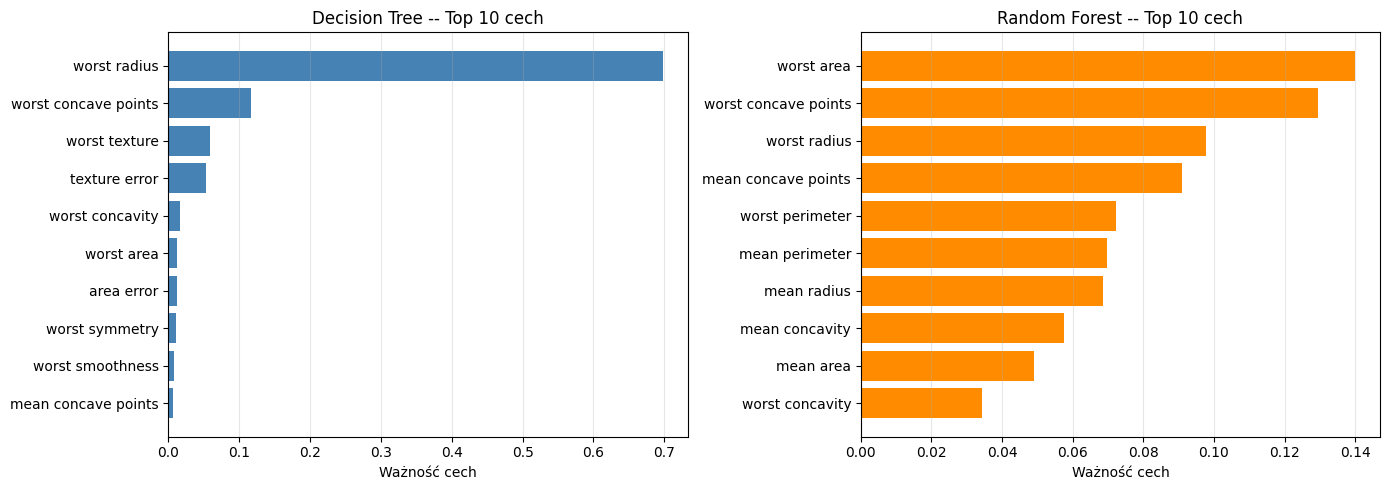

=== WNIOSKI ===
1. Random Forest uśrednia ważność po wielu drzewach -- wykres jest stabilniejszy niż pojedyncze drzewo.
2. W obu modelach w Top 10 często pojawiają się te same cechy (np. worst radius, worst concave points), ale kolejność może się różnić.
3. Pojedyncze drzewo może nadmiernie faworyzować cechy z wczesnych podziałów; RF redukuje ten efekt dzięki baggingowi.


In [ ]:
# Feature importance -- drzewo decyzyjne vs Random Forest
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


def top10(importances, feature_names):
    """Top 10 cech posortowanych malejąco po ważności."""
    idx = np.argsort(importances)[::-1][:10]
    return [feature_names[i] for i in idx], importances[idx]


# 1. Wczytanie danych i podział train/test (80/20, stratyfikacja)
cancer = load_breast_cancer()
feature_names = cancer.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)

# 2. Trening obu modeli (bez standaryzacji -- drzewa tego nie wymagają)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. Top 10 cech dla każdego modelu
tree_names, tree_imp = top10(tree.feature_importances_, feature_names)
rf_names, rf_imp = top10(rf.feature_importances_, feature_names)

# 4. Podwójny wykres barh (obok siebie)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(tree_names[::-1], tree_imp[::-1], color="steelblue")
ax1.set_title("Decision Tree -- Top 10 cech")
ax1.set_xlabel("Ważność cech")
ax1.grid(True, alpha=0.3, axis="x")

ax2.barh(rf_names[::-1], rf_imp[::-1], color="darkorange")
ax2.set_title("Random Forest -- Top 10 cech")
ax2.set_xlabel("Ważność cech")
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# 5. Wnioski
print("=== WNIOSKI ===")
print(
    "1. Random Forest uśrednia ważność po wielu drzewach -- wykres jest stabilniejszy "
    "niż pojedyncze drzewo."
)
print(
    "2. W obu modelach w Top 10 często pojawiają się te same cechy (np. "
    f"{tree_names[0]}, {tree_names[1]}), ale kolejność może się różnić."
)
print(
    "3. Pojedyncze drzewo może nadmiernie faworyzować cechy z wczesnych podziałów; "
    "RF redukuje ten efekt dzięki baggingowi."
)

# Zadanie 7 -- Gradient Boosting baseline
Wytrenuj GradientBoostingClassifier na Breast Cancer.

Wymagania:
- n_estimators=100, learning_rate=0.1, max_depth=3
- Oblicz accuracy, AUC
- Zmierz czas treningu (time.time())

Oczekiwany wynik:
- Metryki i czas treningu


In [ ]:
# Gradient Boosting -- baseline na Breast Cancer
import time
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# 1. Wczytanie danych i podział train/test (80/20, stratyfikacja)
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)

# 2. Trening Gradient Boosting (mierzenie czasu fit)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
)

start_time = time.time()
gb.fit(X_train, y_train)
elapsed_time = time.time() - start_time

# 3. Metryki na zbiorze testowym
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

gb_acc = accuracy_score(y_test, y_pred)
gb_auc = roc_auc_score(y_test, y_proba)

print("=== Gradient Boosting (Breast Cancer) ===")
print(f"Accuracy:      {gb_acc:.4f}")
print(f"AUC:           {gb_auc:.4f}")
print(f"Czas treningu: {elapsed_time:.3f} s")


# Zadanie 8 -- Porównanie 3 algorytmów
Porównaj kNN, Decision Tree i Random Forest na datasecie Iris.

Wymagania:
- Walidacja krzyżowa (cv=5) dla każdego
- Narysuj bar chart ze średnią accuracy i odchyleniem standardowym
- Wskaż najlepszy algorytm

Oczekiwany wynik:
- Wykres porównawczy z errorbar


In [ ]:
# Porównanie 3 algorytmów -- kNN, Decision Tree, Random Forest (Iris)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target

# 2. Definicja modeli (domyślne parametry sklearn)
# kNN wymaga standaryzacji -- algorytm oparty na odległościach
models = {
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Walidacja krzyżowa (cv=5) -- accuracy dla każdego modelu
results = {}
print("=== WALIDACJA KRZYŻOWA (cv=5, Iris) ===")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:15s}  średnia={scores.mean():.4f}  std={scores.std():.4f}")

names = list(results.keys())
means = np.array([results[n].mean() for n in names])
stds = np.array([results[n].std() for n in names])

# 4. Wykres bar chart z errorbar (odchylenie standardowe)
x = np.arange(len(names))
colors = ["steelblue", "seagreen", "darkorange"]

plt.figure(figsize=(8, 5))
plt.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor="black", linewidth=0.6)
plt.xticks(x, names)
plt.ylabel("Accuracy")
plt.title("Porównanie algorytmów -- walidacja krzyżowa (cv=5, Iris)")
plt.ylim(0.85, 1.02)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# 5. Najlepszy algorytm
best_idx = np.argmax(means)
best_name = names[best_idx]
print(f"\nNajlepszy algorytm: {best_name} (średnia accuracy: {means[best_idx]:.4f})")


# Zadanie 11 -- Ensemble na Wine Quality
Porównaj Random Forest, Gradient Boosting i XGBoost na datasecie Wine Quality.

Dataset:
- https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

Wymagania:
- Wczytaj dane, użyj `quality` jako target (binaryzacja: quality >= 7 = "good", < 7 = "not good")
- Porównaj 3 modele z walidacją krzyżową
- Narysuj krzywe ROC na jednym wykresie
- Zmierz czas treningu każdego modelu

Oczekiwany wynik:
- Krzywe ROC, tabela metryk i czasów


Kształt danych: (1599, 11)
Proporcja klasy 'good' (quality >= 7): 0.1357098186366479

=== WALIDACJA KRZYŻOWA (cv=5) ===
Random Forest       AUC=0.8899  std=0.0231
Gradient Boosting   AUC=0.8814  std=0.0034
XGBoost             AUC=0.8789  std=0.0128

=== TABELA METRYK I CZASÓW ===
            Model  CV AUC (średnia)  CV AUC (std)  Test AUC  Czas treningu [s]
    Random Forest            0.8899        0.0231    0.9553             0.1173
Gradient Boosting            0.8814        0.0034    0.8921             0.1558
          XGBoost            0.8789        0.0128    0.9405             0.1361


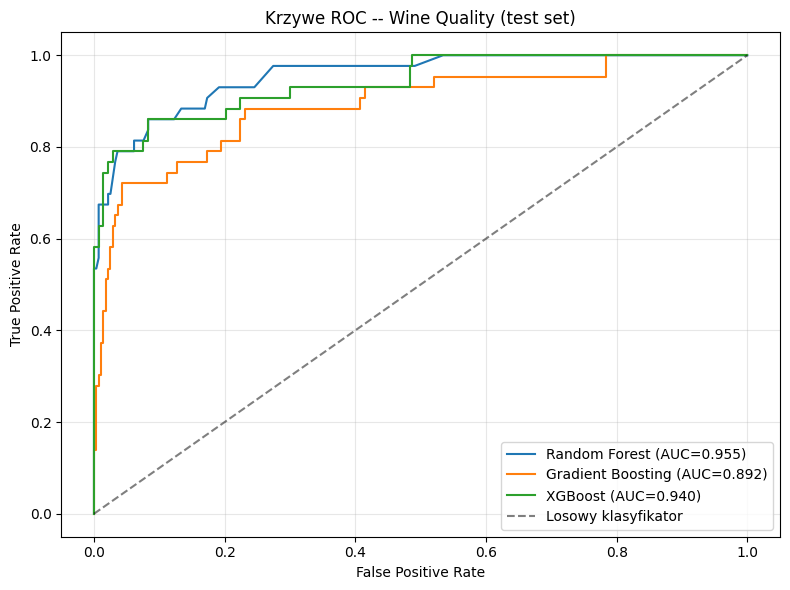

In [14]:
# Ensemble -- Random Forest vs Gradient Boosting vs XGBoost (Wine Quality)
import time
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier

# 1. Wczytanie danych i binaryzacja targetu
url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv"
)
wine = pd.read_csv(url, sep=";")
wine["target"] = (wine["quality"] >= 7).astype(int)

X = wine.drop(columns=["quality", "target"])
y = wine["target"]

print("Kształt danych:", X.shape)
print("Proporcja klasy 'good' (quality >= 7):", y.mean())
print()

# 2. Podział train/test (80/20, stratyfikacja)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Definicja modeli (domyślne parametry sklearn / XGBoost)
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Walidacja krzyżowa (cv=5) + czas treningu + krzywe ROC
rows = []
plt.figure(figsize=(8, 6))

print("=== WALIDACJA KRZYŻOWA (cv=5) ===")
for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:18s}  AUC={cv_auc.mean():.4f}  std={cv_auc.std():.4f}")

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={test_auc:.3f})")

    rows.append({
        "Model": name,
        "CV AUC (średnia)": cv_auc.mean(),
        "CV AUC (std)": cv_auc.std(),
        "Test AUC": test_auc,
        "Czas treningu [s]": train_time,
    })

# 5. Tabela metryk i czasów
tabela = pd.DataFrame(rows)
print("\n=== TABELA METRYK I CZASÓW ===")
print(
    tabela.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x),
    )
)

# 6. Krzywe ROC na jednym wykresie
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Losowy klasyfikator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywe ROC -- Wine Quality (test set)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Zadanie 12 -- Tuning Random Forest
Przeprowadź tuning hiperparametrów Random Forest na Breast Cancer.

Wymagania:
- Użyj RandomizedSearchCV z n_iter=30
- Przestrzeń parametrów: n_estimators (50-300), max_depth (3-20), min_samples_split
- Porównaj domyślny RF vs zoptymalizowany RF
- Wyświetl najlepsze parametry

Oczekiwany wynik:
- Porównanie accuracy: domyślny vs zoptymalizowany


In [15]:
# Tuning Random Forest -- RandomizedSearchCV (Breast Cancer)
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import pandas as pd
from scipy.stats import randint
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Wczytanie danych i podział train/test (80/20, stratyfikacja)
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)

# 2. Baseline -- domyślny Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
default_acc = accuracy_score(y_test, rf_default.predict(X_test))

# 3. RandomizedSearchCV -- przeszukiwanie hiperparametrów
param_dist = {
    "n_estimators": randint(50, 301),
    "max_depth": randint(3, 21),
    "min_samples_split": randint(2, 21),
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
)
search.fit(X_train, y_train)

rf_best = search.best_estimator_
best_acc = accuracy_score(y_test, rf_best.predict(X_test))

# 4. Wyniki
print("=== TUNING RANDOM FOREST (Breast Cancer) ===")
print(f"Najlepsze parametry: {search.best_params_}")
print(f"Najlepsza accuracy (CV): {search.best_score_:.4f}")

porownanie = pd.DataFrame({
    "Model": ["Domyślny RF", "Zoptymalizowany RF"],
    "Accuracy (test)": [default_acc, best_acc],
})

print("\n=== PORÓWNANIE ACCURACY ===")
print(porownanie.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== TUNING RANDOM FOREST (Breast Cancer) ===
Najlepsze parametry: {'max_depth': 11, 'min_samples_split': 3, 'n_estimators': 133}
Najlepsza accuracy (CV): 0.9560

=== PORÓWNANIE ACCURACY ===
             Model  Accuracy (test)
       Domyślny RF           0.9561
Zoptymalizowany RF           0.9474
